In [1]:
# .env 파일에서 API 키를 불러오기 위해 dotenv 라이브러리 사용
from dotenv import load_dotenv

# API 키를 환경변수에서 불러오기
load_dotenv()

True

In [2]:
# LangSmith에서 Agent 추적.
from langchain_teddynote import logging

# 로깅 설정
logging.langsmith("Default_LangGraph_Know")

LangSmith 추적을 시작합니다.
[프로젝트명]
Default_LangGraph_Know


In [3]:
# LangGraph를 사용하기 위해 필요한 라이브러리 import
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_google_genai import ChatGoogleGenerativeAI

class State(TypedDict):
    """ 메시지 정의, list로 정의, add_messages로 메시지 추가 """
    messages: Annotated[list, add_messages]

In [4]:
# Node 구성
llm = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash-exp",
    temperature=0,
    max_tokens=8192,
    top_p=0.95,
)

def chatbot(state: State):
    """ 메시지 호출 및 반환 """
    return {"messages": [llm.invoke(state["messages"])]}

In [5]:
# 그래프 구성
graph_builder = StateGraph(State)

# 노드 이름, 입력 및 출력 정의
graph_builder.add_node("chatbot", chatbot)


In [6]:
graph_builder.add_edge(START, "chatbot")

graph_builder.add_edge("chatbot", END)

In [7]:
graph = graph_builder.compile()

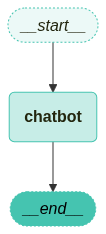

In [8]:
from langchain_teddynote.graphs import visualize_graph


# 그래프 시각화
visualize_graph(graph)

In [10]:
question = "공부하기 좋은 방법 10가지 알려줘"

# 그래프 이벤트 스트리밍
for event in graph.stream({"messages": [("user", question)]}):
    for value in event.values():
        print("Assistant:", value["messages"][-1].content)

Assistant: ## 공부 효율을 높이는 10가지 방법

1.  **나만의 공부 스타일 파악:** 시각, 청각, 운동 감각 등 자신에게 맞는 학습 방식을 찾고 활용하세요. 예를 들어, 시각 학습자라면 그림이나 도표를 활용하고, 청각 학습자라면 강의 내용을 녹음해서 듣는 것이 좋습니다.

2.  **계획적인 학습:** 구체적인 목표를 세우고, 학습 계획을 세분화하여 실천하세요. 하루에 공부할 양을 정하고, 주간 계획, 월간 계획으로 확장해 나가면 좋습니다. 계획을 달성했을 때는 스스로에게 작은 보상을 주는 것도 동기 부여에 도움이 됩니다.

3.  **시간 관리:** 집중력이 높은 시간대를 파악하여 중요한 과목을 공부하고, 뽀모도로 기법(25분 집중 후 5분 휴식) 등을 활용하여 집중력을 유지하세요. 스마트폰 알림을 끄거나 방해 요소를 최소화하는 것도 중요합니다.

4.  **능동적인 학습:** 단순히 읽고 암기하는 것보다, 내용을 요약하거나 자신만의 방식으로 재구성하여 설명하는 연습을 하세요. 마인드 맵, 플래시 카드, 퀴즈 등 다양한 방법을 활용하면 더욱 효과적입니다.

5.  **이해 중심 학습:** 무작정 암기하기보다, 개념과 원리를 정확하게 이해하는 데 집중하세요. 모르는 부분은 질문하거나 관련 자료를 찾아보며 궁금증을 해결해야 합니다.

6.  **반복 학습:** 잊어버리기 쉬운 내용은 주기적으로 복습하여 장기 기억으로 전환하세요. 에빙하우스의 망각 곡선을 참고하여 복습 주기를 설정하는 것도 좋은 방법입니다.

7.  **다양한 학습 자료 활용:** 교과서 외에도 참고서, 인터넷 강의, 유튜브 영상 등 다양한 학습 자료를 활용하여 폭넓은 지식을 습득하세요.

8.  **건강 관리:** 규칙적인 수면, 균형 잡힌 식단, 꾸준한 운동은 집중력과 기억력 향상에 필수적입니다. 스트레스를 해소하고 긍정적인 마음을 유지하는 것도 중요합니다.

9.  **스터디 그룹 활용:** 친구들과 함께 공부하며 서로 가르치고 배우는 과정을 통해 이해도를 높이고, 동기 부